<a href="https://colab.research.google.com/github/Shashank-sketchAl/ML-90-Day-Challenge-/blob/main/D1_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
#from google.colab import files
#uploaded = files.upload()

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
df =pd.read_csv('titanic.csv')

In [63]:
df.head()

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,"Heikkinen, Miss. Laina",3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,1,0,113803,53.1000,C123,S,1
4,5,"Allen, Mr. William Henry",3,male,35.0,0,0,373450,8.0500,NaN,S,0


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Name         891 non-null    object 
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
 11  Survived     891 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [65]:
df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Survived
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,2.308642,29.699118,0.523008,0.381594,32.204208,0.383838
std,257.353842,0.836071,14.526497,1.102743,0.806057,49.693429,0.486592
min,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,2.000000,20.125000,0.000000,0.000000,7.910400,0.000000
50%,446.000000,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,668.500000,3.000000,38.000000,1.000000,0.000000,31.000000,1.000000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000


In [66]:
df.isnull().sum()

,0
PassengerId,0
Name,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


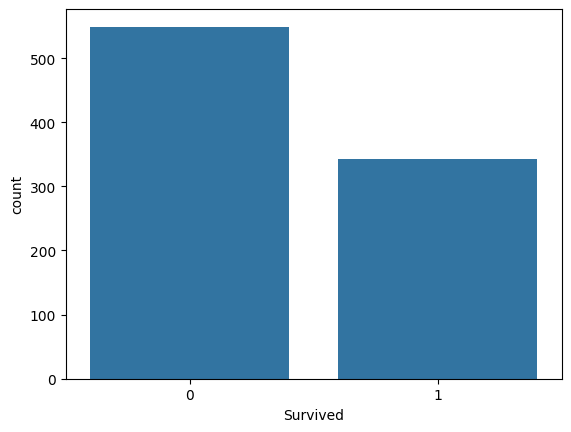

In [67]:
sns.countplot(x='Survived',data=df)
plt.show()

#0 -> Died
#1 -> Survived

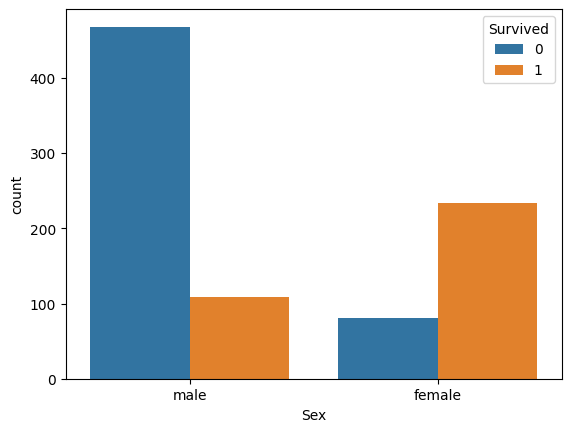

In [68]:
sns.countplot(x='Sex',hue='Survived',data=df)
plt.show()

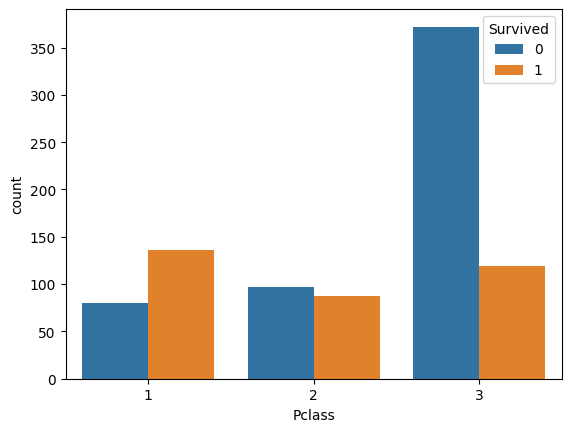

In [69]:
sns.countplot(x='Pclass',hue='Survived',data=df)
plt.show()

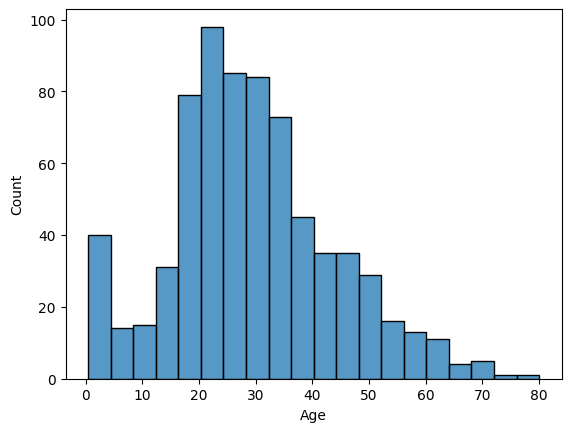

In [70]:
sns.histplot(df['Age'], bins=20)
plt.show()

In [71]:
X = df.drop('Survived', axis=1)

y = df['Survived']

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression as lr
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [77]:
import numpy as np
from sklearn.impute import SimpleImputer

scaler = StandardScaler()

numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

X_train_numeric = X_train[numerical_cols].copy()
X_test_numeric = X_test[numerical_cols].copy()

imputer = SimpleImputer(strategy='mean')

# Fit imputer on the training numerical data and transform both train and test
# This ensures all numerical columns with NaNs are handled
X_train_numeric_imputed = imputer.fit_transform(X_train_numeric)
X_test_numeric_imputed = imputer.transform(X_test_numeric)

X_train_scaled = scaler.fit_transform(X_train_numeric_imputed)
X_test_scaled = scaler.transform(X_test_numeric_imputed)

In [78]:
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Accuracy:",accuracy_score(y_test,y_pred_lr))

Accuracy: 0.7318435754189944


In [79]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled,y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("Accuracy:",accuracy_score(y_test,y_pred_knn))

Accuracy: 0.7206703910614525


In [81]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_scaled,y_train)

y_pred_dt = dt.predict(X_test_scaled)

print("Accuracy:",accuracy_score(y_test,y_pred_dt))

Accuracy: 0.6368715083798883


In [82]:
results = pd.DataFrame({
    'Model':['Logistic Regression',
             'KNN',
             'Decision Tree'],
    'Accuracy':[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_knn),
        accuracy_score(y_test,y_pred_dt)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.731844
1                  KNN  0.720670
2        Decision Tree  0.636872


In [83]:
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.72      0.90      0.80       105
           1       0.77      0.50      0.61        74

    accuracy                           0.73       179
   macro avg       0.74      0.70      0.70       179
weighted avg       0.74      0.73      0.72       179



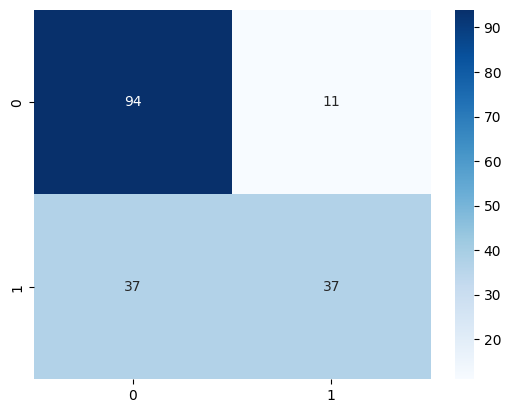

In [84]:
cm = confusion_matrix(y_test,y_pred_lr)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.show()